## Imports

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
import pygame
import time

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from dataclasses import dataclass
from collections import deque

pygame 2.6.1 (SDL 2.28.4, Python 3.11.9)
Hello from the pygame community. https://www.pygame.org/contribute.html


## Environment class

In [2]:
class VacuumGridEnv:
    def __init__(self, rows=5, cols=5, dirty_positions=None, max_steps=100):
        self.rows = rows
        self.cols = cols
        self.max_steps = max_steps

        self.state_size = rows * cols * 2
        self.action_size = 4

        if dirty_positions is None:
            dirty_positions = [(1, 1), (2, 3), (4, 4)]

        self.initial_dirty_positions = set(dirty_positions)

        # 0 = North, 1 = South, 2 = West, 3 = East
        self.actions = {
            0: (-1, 0),
            1: ( 1, 0),
            2: ( 0,-1),
            3: ( 0, 1)
        }

        self.reset()

    def reset(self):
        self.agent_pos = (0, 0)
        self.dirty_positions = set(self.initial_dirty_positions)
        self.steps_taken = 0
        self.visited = set()
        self.visited.add(self.agent_pos)

        if self.agent_pos in self.dirty_positions:
            self.dirty_positions.remove(self.agent_pos)

        return self.get_state()

    def get_state(self):
        agent_grid = np.zeros((self.rows, self.cols), dtype=np.float32)
        dirt_grid = np.zeros((self.rows, self.cols), dtype=np.float32)

        ar, ac = self.agent_pos
        agent_grid[ar, ac] = 1.0

        for r, c in self.dirty_positions:
            dirt_grid[r, c] = 1.0

        return np.concatenate([agent_grid.flatten(), dirt_grid.flatten()])

    def nearest_dirt_distance(self, pos):
        if len(self.dirty_positions) == 0:
            return 0
        r, c = pos
        return min(abs(r - dr) + abs(c - dc) for dr, dc in self.dirty_positions)

    def step(self, action):
        self.steps_taken += 1

        reward = -1.0
        done = False
        cleaned_tile = False
        invalid_move = False

        old_distance = self.nearest_dirt_distance(self.agent_pos)

        dr, dc = self.actions[action]
        r, c = self.agent_pos
        nr, nc = r + dr, c + dc

        if nr < 0 or nr >= self.rows or nc < 0 or nc >= self.cols:
            nr, nc = r, c
            reward -= 5.0
            invalid_move = True

        self.agent_pos = (nr, nc)

        if self.agent_pos in self.dirty_positions:
            self.dirty_positions.remove(self.agent_pos)
            reward += 10.0
            cleaned_tile = True

        new_distance = self.nearest_dirt_distance(self.agent_pos)

        if self.agent_pos in self.visited and not cleaned_tile and not invalid_move:
            reward -= 1.2

        if not cleaned_tile and not invalid_move:
            if new_distance < old_distance:
                reward += 0.5
            elif new_distance > old_distance:
                reward -= 0.5

        self.visited.add(self.agent_pos)

        if len(self.dirty_positions) == 0:
            reward += 50.0
            done = True

        if self.steps_taken >= self.max_steps:
            done = True

        info = {
            "cleaned_tile": cleaned_tile,
            "invalid_move": invalid_move,
            "remaining_dirt": len(self.dirty_positions),
            "steps_taken": self.steps_taken
        }

        return self.get_state(), reward, done, info

    def render_text(self):
        grid = [["." for _ in range(self.cols)] for _ in range(self.rows)]

        for r, c in self.dirty_positions:
            grid[r][c] = "D"

        ar, ac = self.agent_pos
        grid[ar][ac] = "A"

        print("-" * (self.cols * 2))
        for row in grid:
            print(" ".join(row))
        print("-" * (self.cols * 2))

## Create and test the environment

In [3]:
env = VacuumGridEnv(
    rows=5,
    cols=5,
    dirty_positions=[(1, 1), (2, 3), (4, 4)],
    max_steps=50
)

state = env.reset()
env.render_text()
print("State shape:", state.shape)

----------
A . . . .
. D . . .
. . . D .
. . . . .
. . . . D
----------
State shape: (50,)


## Manual action test

In [4]:
env = VacuumGridEnv(
    rows=5,
    cols=5,
    dirty_positions=[(1, 1), (2, 3), (4, 4)],
    max_steps=30
)

state = env.reset()
done = False
total_reward = 0

while not done:
    action = random.randint(0, 3)
    next_state, reward, done, info = env.step(action)
    total_reward += reward

    env.render_text()
    print("Reward:", reward, "| Info:", info)
    print()

print("Episode finished")
print("Total reward:", total_reward)

----------
A . . . .
. D . . .
. . . D .
. . . . .
. . . . D
----------
Reward: -6.0 | Info: {'cleaned_tile': False, 'invalid_move': True, 'remaining_dirt': 3, 'steps_taken': 1}

----------
A . . . .
. D . . .
. . . D .
. . . . .
. . . . D
----------
Reward: -6.0 | Info: {'cleaned_tile': False, 'invalid_move': True, 'remaining_dirt': 3, 'steps_taken': 2}

----------
. A . . .
. D . . .
. . . D .
. . . . .
. . . . D
----------
Reward: -0.5 | Info: {'cleaned_tile': False, 'invalid_move': False, 'remaining_dirt': 3, 'steps_taken': 3}

----------
. A . . .
. D . . .
. . . D .
. . . . .
. . . . D
----------
Reward: -6.0 | Info: {'cleaned_tile': False, 'invalid_move': True, 'remaining_dirt': 3, 'steps_taken': 4}

----------
. . . . .
. A . . .
. . . D .
. . . . .
. . . . D
----------
Reward: 9.0 | Info: {'cleaned_tile': True, 'invalid_move': False, 'remaining_dirt': 2, 'steps_taken': 5}

----------
. A . . .
. . . . .
. . . D .
. . . . .
. . . . D
----------
Reward: -2.7 | Info: {'cleaned_ti

## Random-agent test

In [5]:
def render_pygame(env, cell_size=80):
    pygame.init()

    width = env.cols * cell_size
    height = env.rows * cell_size
    screen = pygame.display.set_mode((width, height))
    pygame.display.set_caption("Vacuum Grid World")

    WHITE = (255, 255, 255)
    GRAY = (180, 180, 180)
    BROWN = (139, 69, 19)
    BLUE = (50, 100, 255)

    screen.fill(WHITE)

    for r in range(env.rows):
        for c in range(env.cols):
            rect = pygame.Rect(c * cell_size, r * cell_size, cell_size, cell_size)

            if (r, c) in env.dirty_positions:
                pygame.draw.rect(screen, BROWN, rect)
            else:
                pygame.draw.rect(screen, WHITE, rect)

            pygame.draw.rect(screen, GRAY, rect, 1)

    ar, ac = env.agent_pos
    center_x = ac * cell_size + cell_size // 2
    center_y = ar * cell_size + cell_size // 2
    pygame.draw.circle(screen, BLUE, (center_x, center_y), cell_size // 3)

    pygame.display.flip()
    
    running = True
    start_time = pygame.time.get_ticks()
    
    while running:
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                running = False
    
        if pygame.time.get_ticks() - start_time > 2000:
            running = False
    
    pygame.quit()

## Pygame visualization

In [6]:
env = VacuumGridEnv(
    rows=5,
    cols=5,
    dirty_positions=[(1, 1), (2, 3), (4, 4)],
    max_steps=50
)

env.reset()
render_pygame(env)

## Pygame renderer

In [7]:
def run_random_episode_pygame(env, delay=300, cell_size=80):
    pygame.init()

    width = env.cols * cell_size
    height = env.rows * cell_size
    screen = pygame.display.set_mode((width, height))
    pygame.display.set_caption("Vacuum Random Agent")

    WHITE = (255, 255, 255)
    GRAY = (180, 180, 180)
    BROWN = (139, 69, 19)
    BLUE = (50, 100, 255)

    state = env.reset()
    done = False
    total_reward = 0

    while not done:
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                done = True

        action = random.randint(0, 3)
        state, reward, done, info = env.step(action)
        total_reward += reward

        screen.fill(WHITE)

        for r in range(env.rows):
            for c in range(env.cols):
                rect = pygame.Rect(c * cell_size, r * cell_size, cell_size, cell_size)

                if (r, c) in env.dirty_positions:
                    pygame.draw.rect(screen, BROWN, rect)
                else:
                    pygame.draw.rect(screen, WHITE, rect)

                pygame.draw.rect(screen, GRAY, rect, 1)

        ar, ac = env.agent_pos
        center_x = ac * cell_size + cell_size // 2
        center_y = ar * cell_size + cell_size // 2
        pygame.draw.circle(screen, BLUE, (center_x, center_y), cell_size // 3)

        pygame.display.flip()
        pygame.time.delay(delay)

    pygame.quit()
    print("Total reward:", total_reward)

## Replay Buffer

In [8]:
class ReplayBuffer:
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        return (
            np.array(states, dtype=np.float32),
            np.array(actions, dtype=np.int64),
            np.array(rewards, dtype=np.float32),
            np.array(next_states, dtype=np.float32),
            np.array(dones, dtype=np.float32)
        )

    def __len__(self):
        return len(self.buffer)

## DQN model

In [9]:
class DQN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(DQN, self).__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, output_dim)
        )

    def forward(self, x):
        return self.net(x)

## Device setup

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## Create environment and networks

In [11]:
env = VacuumGridEnv(
    rows=5,
    cols=5,
    dirty_positions=[(1, 1), (2, 3), (4, 4)],
    max_steps=50
)

policy_net = DQN(env.state_size, env.action_size).to(device)
target_net = DQN(env.state_size, env.action_size).to(device)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

optimizer = optim.Adam(policy_net.parameters(), lr=5e-4)
replay_buffer = ReplayBuffer(capacity=20000)

## Hyperparameters

In [12]:
GAMMA = 0.99
BATCH_SIZE = 64

EPSILON_START = 1.0
EPSILON_END = 0.05
EPSILON_DECAY = 0.997

TARGET_UPDATE_FREQ = 5
NUM_EPISODES = 1500

## Epsilon-greedy action selection

In [13]:
def select_action(state, policy_net, epsilon, action_size):
    if random.random() < epsilon:
        return random.randrange(action_size)

    state_tensor = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)

    with torch.no_grad():
        q_values = policy_net(state_tensor)

    return q_values.argmax(dim=1).item()

## Training step function

In [14]:
def train_dqn(policy_net, target_net, replay_buffer, optimizer, batch_size, gamma):
    if len(replay_buffer) < batch_size:
        return None

    states, actions, rewards, next_states, dones = replay_buffer.sample(batch_size)

    states = torch.tensor(states, dtype=torch.float32, device=device)
    actions = torch.tensor(actions, dtype=torch.int64, device=device).unsqueeze(1)
    rewards = torch.tensor(rewards, dtype=torch.float32, device=device).unsqueeze(1)
    next_states = torch.tensor(next_states, dtype=torch.float32, device=device)
    dones = torch.tensor(dones, dtype=torch.float32, device=device).unsqueeze(1)

    current_q_values = policy_net(states).gather(1, actions)

    with torch.no_grad():
        max_next_q_values = target_net(next_states).max(dim=1, keepdim=True)[0]
        target_q_values = rewards + gamma * max_next_q_values * (1 - dones)

    loss = F.mse_loss(current_q_values, target_q_values)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item()

## Full training loop

In [15]:
episode_rewards = []
episode_steps = []
episode_losses = []

epsilon = EPSILON_START

for episode in range(NUM_EPISODES):
    state = env.reset()
    total_reward = 0
    losses = []

    for step in range(env.max_steps):
        action = select_action(state, policy_net, epsilon, env.action_size)
        next_state, reward, done, info = env.step(action)

        replay_buffer.push(state, action, reward, next_state, done)

        loss = train_dqn(
            policy_net,
            target_net,
            replay_buffer,
            optimizer,
            BATCH_SIZE,
            GAMMA
        )

        if loss is not None:
            losses.append(loss)

        state = next_state
        total_reward += reward

        if done:
            break

    episode_rewards.append(total_reward)
    episode_steps.append(step + 1)
    episode_losses.append(np.mean(losses) if losses else 0)

    epsilon = max(EPSILON_END, epsilon * EPSILON_DECAY)

    if (episode + 1) % TARGET_UPDATE_FREQ == 0:
        target_net.load_state_dict(policy_net.state_dict())

    if (episode + 1) % 25 == 0:
        print(f"Episode {episode+1}/{NUM_EPISODES} | Reward: {total_reward:.2f} | Steps: {step+1} | Epsilon: {epsilon:.3f}")

Episode 25/1500 | Reward: -77.20 | Steps: 50 | Epsilon: 0.928
Episode 50/1500 | Reward: 43.30 | Steps: 22 | Epsilon: 0.861
Episode 75/1500 | Reward: 25.70 | Steps: 22 | Epsilon: 0.798
Episode 100/1500 | Reward: 21.70 | Steps: 30 | Epsilon: 0.740
Episode 125/1500 | Reward: 74.50 | Steps: 8 | Epsilon: 0.687
Episode 150/1500 | Reward: 52.50 | Steps: 15 | Epsilon: 0.637
Episode 175/1500 | Reward: 68.50 | Steps: 9 | Epsilon: 0.591
Episode 200/1500 | Reward: 54.10 | Steps: 16 | Epsilon: 0.548
Episode 225/1500 | Reward: 52.50 | Steps: 15 | Epsilon: 0.509
Episode 250/1500 | Reward: 60.90 | Steps: 13 | Epsilon: 0.472
Episode 275/1500 | Reward: 57.70 | Steps: 15 | Epsilon: 0.438
Episode 300/1500 | Reward: 9.70 | Steps: 27 | Epsilon: 0.406
Episode 325/1500 | Reward: 72.50 | Steps: 10 | Epsilon: 0.377
Episode 350/1500 | Reward: 35.70 | Steps: 21 | Epsilon: 0.349
Episode 375/1500 | Reward: 74.50 | Steps: 8 | Epsilon: 0.324
Episode 400/1500 | Reward: 62.50 | Steps: 14 | Epsilon: 0.301
Episode 425/15

# Moving average plot for rewards

In [16]:
def moving_average(values, window=50):
    if len(values) < window:
        return np.array(values)
    return np.convolve(values, np.ones(window) / window, mode="valid")

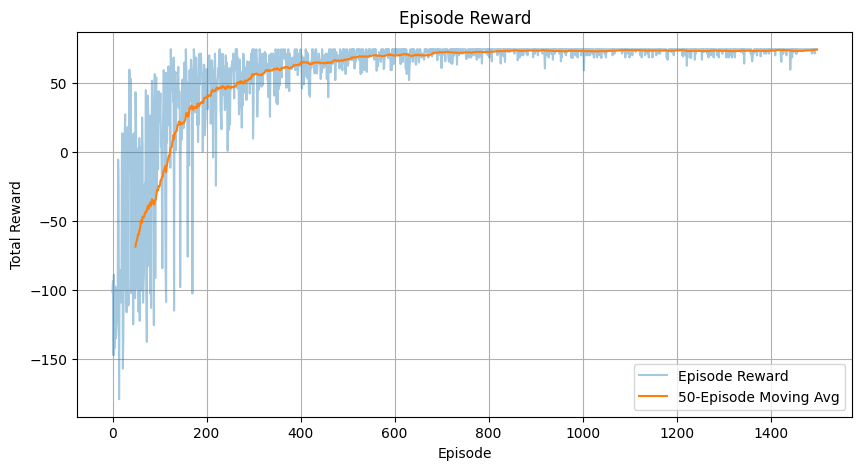

In [17]:
plt.figure(figsize=(10, 5))
plt.plot(episode_rewards, alpha=0.4, label="Episode Reward")
plt.plot(range(49, len(episode_rewards)), moving_average(episode_rewards, 50), label="50-Episode Moving Avg")
plt.title("Episode Reward")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.grid(True)
plt.legend()
plt.show()

# Moving average plot for steps

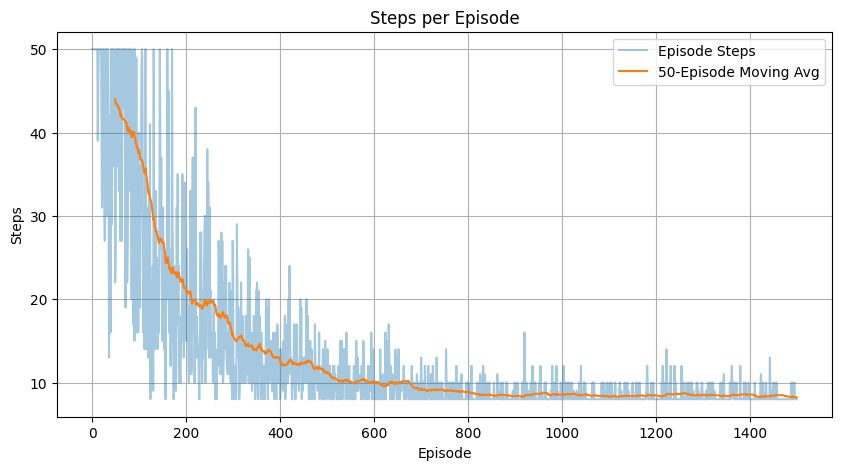

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(episode_steps, alpha=0.4, label="Episode Steps")
plt.plot(range(49, len(episode_steps)), moving_average(episode_steps, 50), label="50-Episode Moving Avg")
plt.title("Steps per Episode")
plt.xlabel("Episode")
plt.ylabel("Steps")
plt.grid(True)
plt.legend()
plt.show()

## Plot learning curves

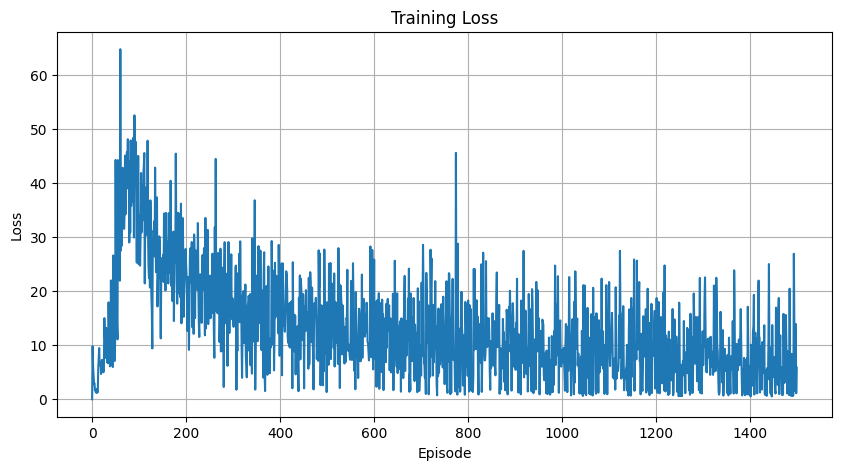

In [19]:
plt.figure(figsize=(10, 5))
plt.plot(episode_losses)
plt.title("Training Loss")
plt.xlabel("Episode")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

## Test the trained agent in text mode

In [20]:
def run_trained_agent_text(env, policy_net):
    state = env.reset()
    done = False
    total_reward = 0

    print("Initial state:")
    env.render_text()

    while not done:
        state_tensor = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)

        with torch.no_grad():
            action = policy_net(state_tensor).argmax(dim=1).item()

        state, reward, done, info = env.step(action)
        total_reward += reward

        print(f"Action: {action}, Reward: {reward}, Info: {info}")
        env.render_text()

    print("Final total reward:", total_reward)

In [21]:
run_trained_agent_text(env, policy_net)

Initial state:
----------
A . . . .
. D . . .
. . . D .
. . . . .
. . . . D
----------
Action: 3, Reward: -0.5, Info: {'cleaned_tile': False, 'invalid_move': False, 'remaining_dirt': 3, 'steps_taken': 1}
----------
. A . . .
. D . . .
. . . D .
. . . . .
. . . . D
----------
Action: 1, Reward: 9.0, Info: {'cleaned_tile': True, 'invalid_move': False, 'remaining_dirt': 2, 'steps_taken': 2}
----------
. . . . .
. A . . .
. . . D .
. . . . .
. . . . D
----------
Action: 3, Reward: -0.5, Info: {'cleaned_tile': False, 'invalid_move': False, 'remaining_dirt': 2, 'steps_taken': 3}
----------
. . . . .
. . A . .
. . . D .
. . . . .
. . . . D
----------
Action: 3, Reward: -0.5, Info: {'cleaned_tile': False, 'invalid_move': False, 'remaining_dirt': 2, 'steps_taken': 4}
----------
. . . . .
. . . A .
. . . D .
. . . . .
. . . . D
----------
Action: 1, Reward: 9.0, Info: {'cleaned_tile': True, 'invalid_move': False, 'remaining_dirt': 1, 'steps_taken': 5}
----------
. . . . .
. . . . .
. . . A .
. .

## Test the trained agent with pygame

In [22]:
def run_trained_agent_pygame(env, policy_net, delay=300, cell_size=80):
    pygame.init()

    width = env.cols * cell_size
    height = env.rows * cell_size
    screen = pygame.display.set_mode((width, height))
    pygame.display.set_caption("Trained Vacuum Agent")

    WHITE = (255, 255, 255)
    GRAY = (180, 180, 180)
    BROWN = (139, 69, 19)
    BLUE = (50, 100, 255)

    state = env.reset()
    done = False
    total_reward = 0

    while not done:
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                done = True

        state_tensor = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)

        with torch.no_grad():
            action = policy_net(state_tensor).argmax(dim=1).item()

        state, reward, done, info = env.step(action)
        total_reward += reward

        screen.fill(WHITE)

        for r in range(env.rows):
            for c in range(env.cols):
                rect = pygame.Rect(c * cell_size, r * cell_size, cell_size, cell_size)

                if (r, c) in env.dirty_positions:
                    pygame.draw.rect(screen, BROWN, rect)
                else:
                    pygame.draw.rect(screen, WHITE, rect)

                pygame.draw.rect(screen, GRAY, rect, 1)

        ar, ac = env.agent_pos
        center_x = ac * cell_size + cell_size // 2
        center_y = ar * cell_size + cell_size // 2
        pygame.draw.circle(screen, BLUE, (center_x, center_y), cell_size // 3)

        pygame.display.flip()
        pygame.time.delay(delay)

    pygame.quit()
    print("Final total reward:", total_reward)

In [23]:
run_trained_agent_pygame(env, policy_net)

Final total reward: 74.5


In [24]:
print("Best reward:", max(episode_rewards))
print("Last 20 episode average reward:", np.mean(episode_rewards[-20:]))
print("Last 20 episode average steps:", np.mean(episode_steps[-20:]))

Best reward: 74.5
Last 20 episode average reward: 74.08
Last 20 episode average steps: 8.3


# SAVE THE FILE

In [25]:
torch.save(policy_net.state_dict(), "dqn_vacuum_5x5.pth")
print("5x5 model saved successfully.")

5x5 model saved successfully.


# Load model later

In [26]:
loaded_policy_net = DQN(env.state_size, env.action_size).to(device)
loaded_policy_net.load_state_dict(torch.load("dqn_vacuum_5x5.pth", map_location=device))
loaded_policy_net.eval()

print("5x5 model loaded successfully.")

5x5 model loaded successfully.


# Creating a 10x10 environment 

In [27]:
env_10 = VacuumGridEnv(
    rows=10,
    cols=10,
    dirty_positions=[(1, 2), (2, 7), (4, 4), (6, 1), (7, 8)],
    max_steps=150
)

print("State size:", env_10.state_size)
print("Action size:", env_10.action_size)

state = env_10.reset()
env_10.render_text()

State size: 200
Action size: 4
--------------------
A . . . . . . . . .
. . D . . . . . . .
. . . . . . . D . .
. . . . . . . . . .
. . . . D . . . . .
. . . . . . . . . .
. D . . . . . . . .
. . . . . . . . D .
. . . . . . . . . .
. . . . . . . . . .
--------------------


# Creating DQN for 10x10

In [28]:
policy_net_10 = DQN(env_10.state_size, env_10.action_size).to(device)
target_net_10 = DQN(env_10.state_size, env_10.action_size).to(device)

target_net_10.load_state_dict(policy_net_10.state_dict())
target_net_10.eval()

optimizer_10 = optim.Adam(policy_net_10.parameters(), lr=5e-4)
replay_buffer_10 = ReplayBuffer(capacity=30000)

print("10x10 model initialized.")

10x10 model initialized.


# Hyperparameters for the 10x10

In [29]:
GAMMA_10 = 0.99
BATCH_SIZE_10 = 64

EPSILON_START_10 = 1.0
EPSILON_END_10 = 0.05
EPSILON_DECAY_10 = 0.998

TARGET_UPDATE_FREQ_10 = 5
NUM_EPISODES_10 = 2500

# 10×10 training loop

In [30]:
episode_rewards_10 = []
episode_steps_10 = []
episode_losses_10 = []

epsilon_10 = EPSILON_START_10

for episode in range(NUM_EPISODES_10):
    state = env_10.reset()
    total_reward = 0
    losses = []

    for step in range(env_10.max_steps):
        action = select_action(state, policy_net_10, epsilon_10, env_10.action_size)
        next_state, reward, done, info = env_10.step(action)

        replay_buffer_10.push(state, action, reward, next_state, done)

        loss = train_dqn(
            policy_net_10,
            target_net_10,
            replay_buffer_10,
            optimizer_10,
            BATCH_SIZE_10,
            GAMMA_10
        )

        if loss is not None:
            losses.append(loss)

        state = next_state
        total_reward += reward

        if done:
            break

    episode_rewards_10.append(total_reward)
    episode_steps_10.append(step + 1)
    episode_losses_10.append(np.mean(losses) if losses else 0)

    epsilon_10 = max(EPSILON_END_10, epsilon_10 * EPSILON_DECAY_10)

    if (episode + 1) % TARGET_UPDATE_FREQ_10 == 0:
        target_net_10.load_state_dict(policy_net_10.state_dict())

    if (episode + 1) % 50 == 0:
        print(f"Episode {episode+1}/{NUM_EPISODES_10} | Reward: {total_reward:.2f} | Steps: {step+1} | Epsilon: {epsilon_10:.3f}")

Episode 50/2500 | Reward: -274.50 | Steps: 150 | Epsilon: 0.905
Episode 100/2500 | Reward: -75.60 | Steps: 103 | Epsilon: 0.819
Episode 150/2500 | Reward: -45.10 | Steps: 88 | Epsilon: 0.741
Episode 200/2500 | Reward: -8.90 | Steps: 76 | Epsilon: 0.670
Episode 250/2500 | Reward: 9.70 | Steps: 61 | Epsilon: 0.606
Episode 300/2500 | Reward: 58.80 | Steps: 40 | Epsilon: 0.548
Episode 350/2500 | Reward: -56.20 | Steps: 96 | Epsilon: 0.496
Episode 400/2500 | Reward: -33.20 | Steps: 86 | Epsilon: 0.449
Episode 450/2500 | Reward: -8.60 | Steps: 73 | Epsilon: 0.406
Episode 500/2500 | Reward: 42.40 | Steps: 48 | Epsilon: 0.368
Episode 550/2500 | Reward: 59.70 | Steps: 39 | Epsilon: 0.333
Episode 600/2500 | Reward: 64.90 | Steps: 35 | Epsilon: 0.301
Episode 650/2500 | Reward: 60.10 | Steps: 36 | Epsilon: 0.272
Episode 700/2500 | Reward: 71.70 | Steps: 33 | Epsilon: 0.246
Episode 750/2500 | Reward: 62.90 | Steps: 37 | Epsilon: 0.223
Episode 800/2500 | Reward: 70.00 | Steps: 35 | Epsilon: 0.202
Ep

# Plot 10x10 training results

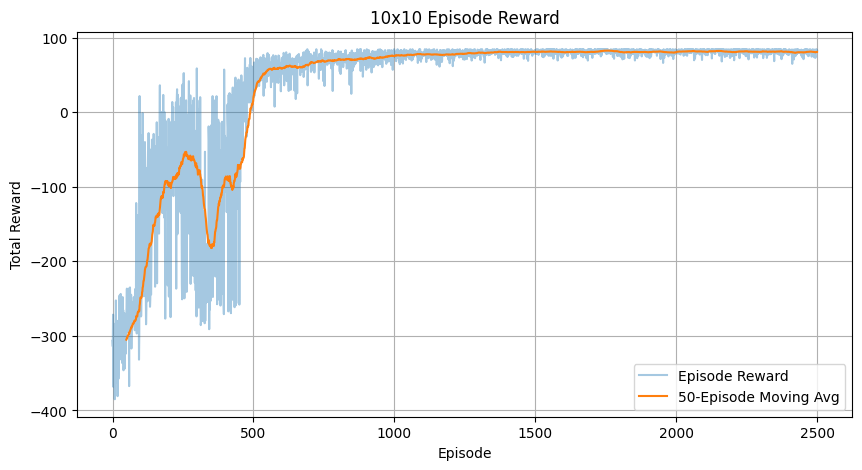

In [31]:
plt.figure(figsize=(10, 5))
plt.plot(episode_rewards_10, alpha=0.4, label="Episode Reward")
plt.plot(range(49, len(episode_rewards_10)), moving_average(episode_rewards_10, 50), label="50-Episode Moving Avg")
plt.title("10x10 Episode Reward")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.grid(True)
plt.legend()
plt.show()

# Stps plot

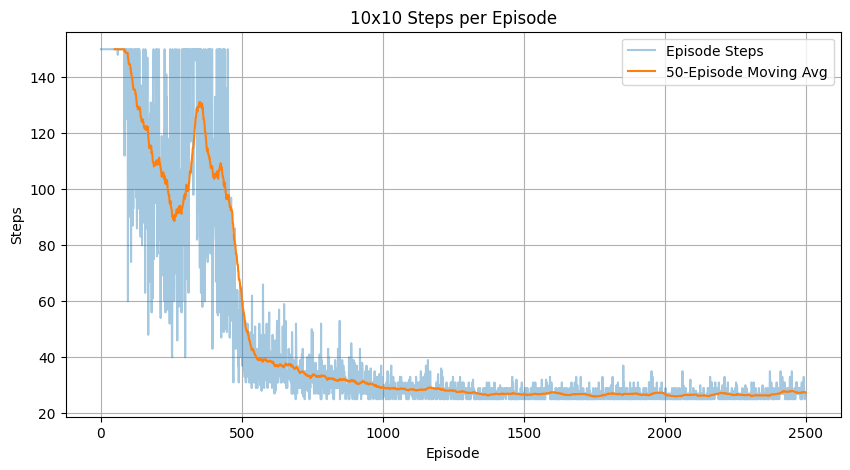

In [32]:
plt.figure(figsize=(10, 5))
plt.plot(episode_steps_10, alpha=0.4, label="Episode Steps")
plt.plot(range(49, len(episode_steps_10)), moving_average(episode_steps_10, 50), label="50-Episode Moving Avg")
plt.title("10x10 Steps per Episode")
plt.xlabel("Episode")
plt.ylabel("Steps")
plt.grid(True)
plt.legend()
plt.show()

# SUMMARY METRICS

In [33]:
print("10x10 Best reward:", np.max(episode_rewards_10))
print("10x10 Last 50 avg reward:", np.mean(episode_rewards_10[-50:]))
print("10x10 Last 50 avg steps:", np.mean(episode_steps_10[-50:]))
print("10x10 Final epsilon:", epsilon_10)

10x10 Best reward: 84.5
10x10 Last 50 avg reward: 80.896
10x10 Last 50 avg steps: 27.42
10x10 Final epsilon: 0.05


# Test the trained 10×10 agent in text mode

In [34]:
run_trained_agent_text(env_10, policy_net_10)

Initial state:
--------------------
A . . . . . . . . .
. . D . . . . . . .
. . . . . . . D . .
. . . . . . . . . .
. . . . D . . . . .
. . . . . . . . . .
. D . . . . . . . .
. . . . . . . . D .
. . . . . . . . . .
. . . . . . . . . .
--------------------
Action: 3, Reward: -0.5, Info: {'cleaned_tile': False, 'invalid_move': False, 'remaining_dirt': 5, 'steps_taken': 1}
--------------------
. A . . . . . . . .
. . D . . . . . . .
. . . . . . . D . .
. . . . . . . . . .
. . . . D . . . . .
. . . . . . . . . .
. D . . . . . . . .
. . . . . . . . D .
. . . . . . . . . .
. . . . . . . . . .
--------------------
Action: 3, Reward: -0.5, Info: {'cleaned_tile': False, 'invalid_move': False, 'remaining_dirt': 5, 'steps_taken': 2}
--------------------
. . A . . . . . . .
. . D . . . . . . .
. . . . . . . D . .
. . . . . . . . . .
. . . . D . . . . .
. . . . . . . . . .
. D . . . . . . . .
. . . . . . . . D .
. . . . . . . . . .
. . . . . . . . . .
--------------------
Action: 1, Reward: 9.0, I

# Test the trained 10×10 agent in text mode

In [35]:
run_trained_agent_pygame(env_10, policy_net_10, delay=150, cell_size=60)

Final total reward: 84.5


# Save the 10×10 model

In [36]:
torch.save(policy_net_10.state_dict(), "dqn_vacuum_10x10.pth")
print("10x10 model saved successfully.")

10x10 model saved successfully.


In [37]:
print("10x10 Best reward:", np.max(episode_rewards_10))
print("10x10 Last 50 avg reward:", np.mean(episode_rewards_10[-50:]))
print("10x10 Last 50 avg steps:", np.mean(episode_steps_10[-50:]))

10x10 Best reward: 84.5
10x10 Last 50 avg reward: 80.896
10x10 Last 50 avg steps: 27.42


# 15 x 15 fixed environment

In [38]:
env_15 = VacuumGridEnv(
    rows=15,
    cols=15,
    dirty_positions=[
        (1, 2), (2, 10), (4, 4), (5, 12), (7, 1),
        (8, 8), (10, 3), (11, 13), (13, 6), (14, 14)
    ],
    max_steps=400
)

print("State size:", env_15.state_size)
print("Action size:", env_15.action_size)

state = env_15.reset()
env_15.render_text()

State size: 450
Action size: 4
------------------------------
A . . . . . . . . . . . . . .
. . D . . . . . . . . . . . .
. . . . . . . . . . D . . . .
. . . . . . . . . . . . . . .
. . . . D . . . . . . . . . .
. . . . . . . . . . . . D . .
. . . . . . . . . . . . . . .
. D . . . . . . . . . . . . .
. . . . . . . . D . . . . . .
. . . . . . . . . . . . . . .
. . . D . . . . . . . . . . .
. . . . . . . . . . . . . D .
. . . . . . . . . . . . . . .
. . . . . . D . . . . . . . .
. . . . . . . . . . . . . . D
------------------------------


15 x 15 Model 

In [39]:
class DQN_Large(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(DQN_Large, self).__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, output_dim)
        )

    def forward(self, x):
        return self.net(x)

# 15 x 15 Networks and Optimizer

In [40]:
policy_net_15 = DQN_Large(env_15.state_size, env_15.action_size).to(device)
target_net_15 = DQN_Large(env_15.state_size, env_15.action_size).to(device)

target_net_15.load_state_dict(policy_net_15.state_dict())
target_net_15.eval()

optimizer_15 = optim.Adam(policy_net_15.parameters(), lr=3e-4)
replay_buffer_15 = ReplayBuffer(capacity=50000)

print("15x15 model initialized.")

15x15 model initialized.


# 15×15 hyperparameters

In [41]:
GAMMA_15 = 0.99
BATCH_SIZE_15 = 128

EPSILON_START_15 = 1.0
EPSILON_END_15 = 0.05
EPSILON_DECAY_15 = 0.999

TARGET_UPDATE_FREQ_15 = 5
NUM_EPISODES_15 = 4000

# 15 x 15 training loop

In [42]:
episode_rewards_15 = []
episode_steps_15 = []
episode_losses_15 = []

epsilon_15 = EPSILON_START_15

for episode in range(NUM_EPISODES_15):
    state = env_15.reset()
    total_reward = 0
    losses = []

    for step in range(env_15.max_steps):
        action = select_action(state, policy_net_15, epsilon_15, env_15.action_size)
        next_state, reward, done, info = env_15.step(action)

        replay_buffer_15.push(state, action, reward, next_state, done)

        loss = train_dqn(
            policy_net_15,
            target_net_15,
            replay_buffer_15,
            optimizer_15,
            BATCH_SIZE_15,
            GAMMA_15
        )

        if loss is not None:
            losses.append(loss)

        state = next_state
        total_reward += reward

        if done:
            break

    episode_rewards_15.append(total_reward)
    episode_steps_15.append(step + 1)
    episode_losses_15.append(np.mean(losses) if losses else 0)

    epsilon_15 = max(EPSILON_END_15, epsilon_15 * EPSILON_DECAY_15)

    if (episode + 1) % TARGET_UPDATE_FREQ_15 == 0:
        target_net_15.load_state_dict(policy_net_15.state_dict())

    if (episode + 1) % 100 == 0:
        print(f"Episode {episode+1}/{NUM_EPISODES_15} | Reward: {total_reward:.2f} | Steps: {step+1} | Epsilon: {epsilon_15:.3f}")

Episode 100/4000 | Reward: -741.20 | Steps: 400 | Epsilon: 0.905
Episode 200/4000 | Reward: -677.80 | Steps: 400 | Epsilon: 0.819
Episode 300/4000 | Reward: -326.90 | Steps: 279 | Epsilon: 0.741
Episode 400/4000 | Reward: -538.20 | Steps: 349 | Epsilon: 0.670
Episode 500/4000 | Reward: -389.70 | Steps: 288 | Epsilon: 0.606
Episode 600/4000 | Reward: -71.40 | Steps: 164 | Epsilon: 0.549
Episode 700/4000 | Reward: -140.30 | Steps: 203 | Epsilon: 0.496
Episode 800/4000 | Reward: 62.10 | Steps: 90 | Epsilon: 0.449
Episode 900/4000 | Reward: -179.20 | Steps: 207 | Epsilon: 0.406
Episode 1000/4000 | Reward: -776.50 | Steps: 400 | Epsilon: 0.368
Episode 1100/4000 | Reward: 36.10 | Steps: 99 | Epsilon: 0.333
Episode 1200/4000 | Reward: 51.10 | Steps: 96 | Epsilon: 0.301
Episode 1300/4000 | Reward: 58.20 | Steps: 92 | Epsilon: 0.272
Episode 1400/4000 | Reward: 86.80 | Steps: 75 | Epsilon: 0.246
Episode 1500/4000 | Reward: 78.30 | Steps: 77 | Epsilon: 0.223
Episode 1600/4000 | Reward: 87.70 | St

# 15 x 15 reward plot

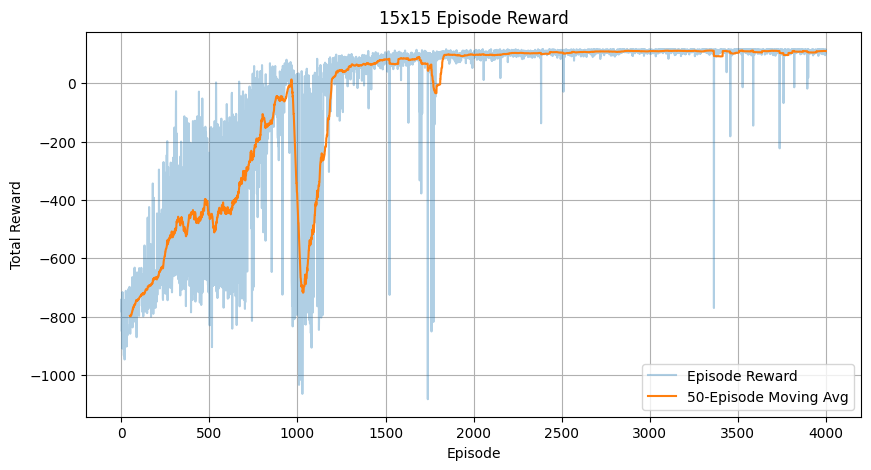

In [43]:
plt.figure(figsize=(10, 5))
plt.plot(episode_rewards_15, alpha=0.35, label="Episode Reward")
plt.plot(
    range(49, len(episode_rewards_15)),
    moving_average(episode_rewards_15, 50),
    label="50-Episode Moving Avg"
)
plt.title("15x15 Episode Reward")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.grid(True)
plt.legend()
plt.show()

# 15 x 15 steps plot

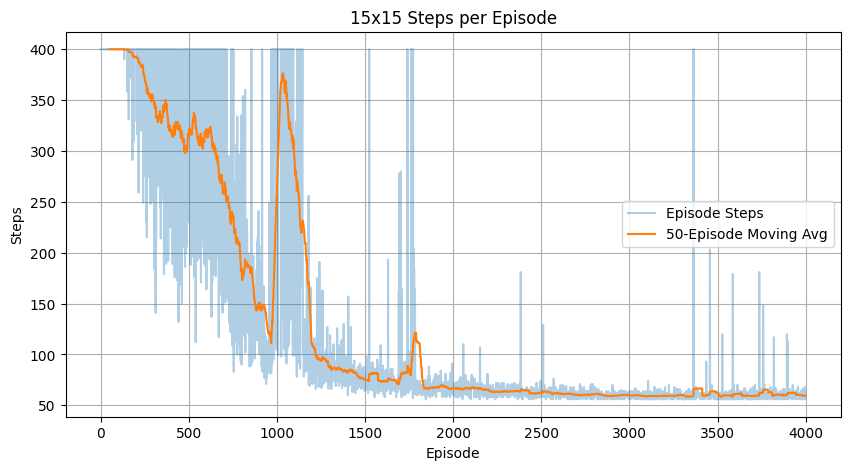

In [44]:
plt.figure(figsize=(10, 5))
plt.plot(episode_steps_15, alpha=0.35, label="Episode Steps")
plt.plot(
    range(49, len(episode_steps_15)),
    moving_average(episode_steps_15, 50),
    label="50-Episode Moving Avg"
)
plt.title("15x15 Steps per Episode")
plt.xlabel("Episode")
plt.ylabel("Steps")
plt.grid(True)
plt.legend()
plt.show()

# 15 x 15 loss plot

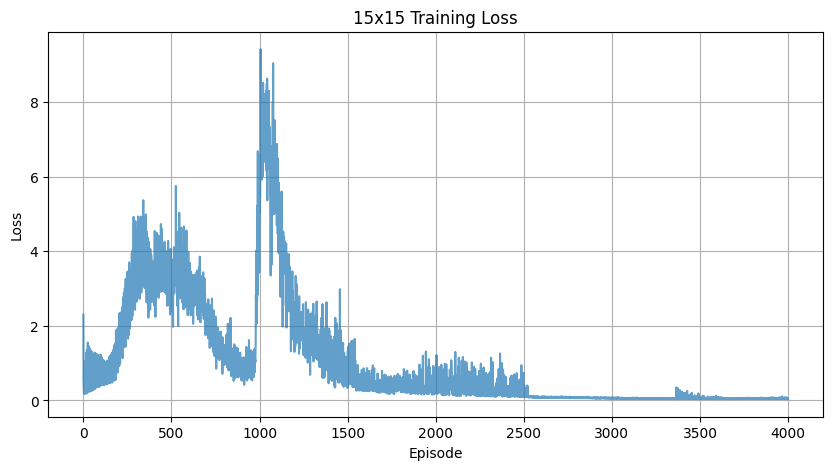

In [45]:
plt.figure(figsize=(10, 5))
plt.plot(episode_losses_15, alpha=0.7)
plt.title("15x15 Training Loss")
plt.xlabel("Episode")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# 15×15 summary metrics

In [46]:
print("15x15 Best reward:", np.max(episode_rewards_15))
print("15x15 Last 50 avg reward:", np.mean(episode_rewards_15[-50:]))
print("15x15 Last 50 avg steps:", np.mean(episode_steps_15[-50:]))
print("15x15 Final epsilon:", epsilon_15)

15x15 Best reward: 116.5
15x15 Last 50 avg reward: 110.166
15x15 Last 50 avg steps: 59.72
15x15 Final epsilon: 0.05


# test trained 15×15 agent in text mode

In [47]:
run_trained_agent_text(env_15, policy_net_15)

Initial state:
------------------------------
A . . . . . . . . . . . . . .
. . D . . . . . . . . . . . .
. . . . . . . . . . D . . . .
. . . . . . . . . . . . . . .
. . . . D . . . . . . . . . .
. . . . . . . . . . . . D . .
. . . . . . . . . . . . . . .
. D . . . . . . . . . . . . .
. . . . . . . . D . . . . . .
. . . . . . . . . . . . . . .
. . . D . . . . . . . . . . .
. . . . . . . . . . . . . D .
. . . . . . . . . . . . . . .
. . . . . . D . . . . . . . .
. . . . . . . . . . . . . . D
------------------------------
Action: 3, Reward: -0.5, Info: {'cleaned_tile': False, 'invalid_move': False, 'remaining_dirt': 10, 'steps_taken': 1}
------------------------------
. A . . . . . . . . . . . . .
. . D . . . . . . . . . . . .
. . . . . . . . . . D . . . .
. . . . . . . . . . . . . . .
. . . . D . . . . . . . . . .
. . . . . . . . . . . . D . .
. . . . . . . . . . . . . . .
. D . . . . . . . . . . . . .
. . . . . . . . D . . . . . .
. . . . . . . . . . . . . . .
. . . D . . . . . . . . 

# test trained 15×15 agent in pygame

In [48]:
run_trained_agent_pygame(env_15, policy_net_15, delay=90, cell_size=40)

Final total reward: 116.5


# save the 15×15 model

In [49]:
torch.save(policy_net_15.state_dict(), "dqn_vacuum_15x15.pth")
print("15x15 model saved successfully.")

15x15 model saved successfully.


In [50]:
policy_net_15.eval()

DQN_Large(
  (net): Sequential(
    (0): Linear(in_features=450, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=4, bias=True)
  )
)

# 